# Econometric Evaluation of Dynamic OLS - Ready Or Not
Rigorous time-series forecasting with chronological Train/Test splits, Heteroskedasticity corrections, and out-of-sample evaluation.

## Cell 1: Setup & Chronological Train-Test Split

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

# Load Data
data_path = '/home/honganh/OOD/ts/time_series_project/data/processed/ReadyOrNot_Final_Merged.csv'
df = pd.read_csv(data_path, parse_dates=['Date'], index_col='Date')
df = df.dropna()

# Create interaction terms for Model 3
df['Discount_Years_Interaction'] = df['Discount_Ratio'] * df['Years_Since_Release']
df['Update_Years_Interaction'] = df['Is_Major_Update'] * df['Years_Since_Release']
df['Lag_Twitch_Avg'] = df['Log_Twitch_Avg'].shift(1)

df = df.dropna()

# Define Target & Features
target = 'Log_Player'
features_m1 = ['Lag_Player', 'Discount_Ratio', 'Is_Weekend', 'Years_Since_Release']
features_m2 = features_m1 + ['Log_Twitch_Avg', 'Is_Major_Update', 'Log_Twitch_Avg'] # remove 'Is_Major_Update', 'Trend_Index'
features_m3 = features_m2 + ['Discount_Years_Interaction'] # remove 'Update_Years_Interaction'

# Chronological Split (Latest 3 months for Test, Rest for Train)
max_date = df.index.max()
split_date = max_date - pd.DateOffset(months=3)
train_df = df[df.index < split_date]
test_df = df[df.index >= split_date]

print(f"Total Data Points: {len(df)}")
print(f"Training Set: {len(train_df)} (Up to {train_df.index[-1].date()})")
print(f"Testing Set: {len(test_df)} ({test_df.index[0].date()} to {test_df.index[-1].date()})")


Total Data Points: 1564
Training Set: 1473 (Up to 2025-12-30)
Testing Set: 91 (2025-12-31 to 2026-03-31)


## Cell 2: Ablation Study - Fitting 3 Models (TRAIN SET ONLY)

In [2]:
y_train = train_df[target]

def fit_model(features):
    X = train_df[features]
    X = sm.add_constant(X)
    return sm.OLS(y_train, X).fit(cov_type='HC3')

model1 = fit_model(features_m1)
model2 = fit_model(features_m2)
model3 = fit_model(features_m3) # As requested, full interaction model as Model 3

print("Models fitted on Training Set with HC3 robust standard errors.\n")

def print_model_stats(name, model):
    print(f"==================== {name} Summary ====================")
    print(f"AIC: {model.aic:.2f} | BIC: {model.bic:.2f} | R-squared: {model.rsquared:.4f}")
    print(model.summary())
    print("\n")

print_model_stats('Model 1', model1)
print_model_stats('Model 2', model2)
print_model_stats('Model 3', model3)


Models fitted on Training Set with HC3 robust standard errors.

==================== Model 1 Summary ====================
AIC: -1671.20 | BIC: -1644.72 | R-squared: 0.9435
                            OLS Regression Results                            
Dep. Variable:             Log_Player   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     7440.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:17:29   Log-Likelihood:                 840.60
No. Observations:                1473   AIC:                            -1671.
Df Residuals:                    1468   BIC:                            -1645.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                          coef    std 

## Cell 3: Rigorous Econometric Diagnostics (On Model 3 Train Residuals)

In [3]:
residuals = model1.resid
X_train_m1 = sm.add_constant(train_df[features_m1])

print("=== Diagnostic Tests on Model 1 Residuals ===\n")

# 1. Breusch-Pagan Test for Heteroskedasticity
bp_test = het_breuschpagan(residuals, X_train_m1)
print("1. Breusch-Pagan Test")
print(f"   Test Statistic (LM): {bp_test[0]:.4f}")
print(f"   P-value: {bp_test[1]:.4f}")
print("   -> If p < 0.05, heteroskedasticity is present, confirming our use of HC3 errors is correct and robust.\n")

# 2. Ljung-Box Test for Autocorrelation
lb_test = acorr_ljungbox(residuals, lags=[1, 5, 10], return_df=True)
print("2. Ljung-Box Test (Lags 1 to 10)")
display(lb_test)
print("   -> If p < 0.05, residuals are autocorrelated.\n")

# 3. ADF Test for Stationarity (Engle-Granger Approach)
adf_test = adfuller(residuals)
print("3. Augmented Dickey-Fuller (ADF) Test on Residuals")
print(f"   Test Statistic: {adf_test[0]:.4f}")
print(f"   P-value: {adf_test[1]:.4e}")
print(f"   Critical Values: {adf_test[4]}")
print("   -> If p < 0.05, residuals are stationary I(0), validating that our regression is NOT spurious.\n")


=== Diagnostic Tests on Model 1 Residuals ===

1. Breusch-Pagan Test
   Test Statistic (LM): 3.7682
   P-value: 0.4383
   -> If p < 0.05, heteroskedasticity is present, confirming our use of HC3 errors is correct and robust.

2. Ljung-Box Test (Lags 1 to 10)


,lb_stat,lb_pvalue
1,67.949897,1.677032e-16
5,226.402077,6.313861e-47
10,777.180136,1.658499e-160


   -> If p < 0.05, residuals are autocorrelated.

3. Augmented Dickey-Fuller (ADF) Test on Residuals
   Test Statistic: -6.2047
   P-value: 5.6939e-08
   Critical Values: {'1%': np.float64(-3.4348616379354793), '5%': np.float64(-2.8635325860671696), '10%': np.float64(-2.567830836482784)}
   -> If p < 0.05, residuals are stationary I(0), validating that our regression is NOT spurious.



In [4]:
residuals = model2.resid
X_train_m2 = sm.add_constant(train_df[features_m2])

print("=== Diagnostic Tests on Model 2 Residuals ===\n")

# 1. Breusch-Pagan Test for Heteroskedasticity
bp_test = het_breuschpagan(residuals, X_train_m2)
print("1. Breusch-Pagan Test")
print(f"   Test Statistic (LM): {bp_test[0]:.4f}")
print(f"   P-value: {bp_test[1]:.4f}")
print("   -> If p < 0.05, heteroskedasticity is present, confirming our use of HC3 errors is correct and robust.\n")

# 2. Ljung-Box Test for Autocorrelation
lb_test = acorr_ljungbox(residuals, lags=[1, 5, 10], return_df=True)
print("2. Ljung-Box Test (Lags 1 to 10)")
display(lb_test)
print("   -> If p < 0.05, residuals are autocorrelated.\n")

# 3. ADF Test for Stationarity (Engle-Granger Approach)
adf_test = adfuller(residuals)
print("3. Augmented Dickey-Fuller (ADF) Test on Residuals")
print(f"   Test Statistic: {adf_test[0]:.4f}")
print(f"   P-value: {adf_test[1]:.4e}")
print(f"   Critical Values: {adf_test[4]}")
print("   -> If p < 0.05, residuals are stationary I(0), validating that our regression is NOT spurious.\n")


=== Diagnostic Tests on Model 2 Residuals ===

1. Breusch-Pagan Test
   Test Statistic (LM): 86.0749
   P-value: 0.0000
   -> If p < 0.05, heteroskedasticity is present, confirming our use of HC3 errors is correct and robust.

2. Ljung-Box Test (Lags 1 to 10)


,lb_stat,lb_pvalue
1,61.639521,4.124563e-15
5,185.785690,3.107999e-38
10,645.776658,2.708790e-132


   -> If p < 0.05, residuals are autocorrelated.

3. Augmented Dickey-Fuller (ADF) Test on Residuals
   Test Statistic: -4.8210
   P-value: 4.9582e-05
   Critical Values: {'1%': np.float64(-3.4348616379354793), '5%': np.float64(-2.8635325860671696), '10%': np.float64(-2.567830836482784)}
   -> If p < 0.05, residuals are stationary I(0), validating that our regression is NOT spurious.



In [5]:
residuals = model3.resid
X_train_m3 = sm.add_constant(train_df[features_m3])

print("=== Diagnostic Tests on Model 3 Residuals ===\n")

# 1. Breusch-Pagan Test for Heteroskedasticity
bp_test = het_breuschpagan(residuals, X_train_m3)
print("1. Breusch-Pagan Test")
print(f"   Test Statistic (LM): {bp_test[0]:.4f}")
print(f"   P-value: {bp_test[1]:.4f}")
print("   -> If p < 0.05, heteroskedasticity is present, confirming our use of HC3 errors is correct and robust.\n")

# 2. Ljung-Box Test for Autocorrelation
lb_test = acorr_ljungbox(residuals, lags=[1, 5, 10], return_df=True)
print("2. Ljung-Box Test (Lags 1 to 10)")
display(lb_test)
print("   -> If p < 0.05, residuals are autocorrelated.\n")

# 3. ADF Test for Stationarity (Engle-Granger Approach)
adf_test = adfuller(residuals)
print("3. Augmented Dickey-Fuller (ADF) Test on Residuals")
print(f"   Test Statistic: {adf_test[0]:.4f}")
print(f"   P-value: {adf_test[1]:.4e}")
print(f"   Critical Values: {adf_test[4]}")
print("   -> If p < 0.05, residuals are stationary I(0), validating that our regression is NOT spurious.\n")


=== Diagnostic Tests on Model 3 Residuals ===

1. Breusch-Pagan Test
   Test Statistic (LM): 87.7896
   P-value: 0.0000
   -> If p < 0.05, heteroskedasticity is present, confirming our use of HC3 errors is correct and robust.

2. Ljung-Box Test (Lags 1 to 10)


,lb_stat,lb_pvalue
1,58.710296,1.826831e-14
5,187.136087,1.599240e-38
10,647.610856,1.094955e-132


   -> If p < 0.05, residuals are autocorrelated.

3. Augmented Dickey-Fuller (ADF) Test on Residuals
   Test Statistic: -5.0099
   P-value: 2.1215e-05
   Critical Values: {'1%': np.float64(-3.4348616379354793), '5%': np.float64(-2.8635325860671696), '10%': np.float64(-2.567830836482784)}
   -> If p < 0.05, residuals are stationary I(0), validating that our regression is NOT spurious.



## Cell 4: Out-of-Sample Forecasting & Evaluation

In [6]:
# Predict on Test Set
X_test_m1 = sm.add_constant(test_df[features_m1])
test_df = test_df.copy()
test_df['Predictions_Log'] = model1.predict(X_test_m1)

# Convert back to original scale utilizing expm1 (because we used log1p)
test_df['Actual_Players'] = np.expm1(test_df[target])
test_df['Predicted_Players'] = np.expm1(test_df['Predictions_Log'])

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(test_df['Actual_Players'], test_df['Predicted_Players']))
mape = np.mean(np.abs((test_df['Actual_Players'] - test_df['Predicted_Players']) / test_df['Actual_Players'])) * 100

print("=== Out-of-Sample Evaluation (Test Set) ===")
print(f"RMSE: {rmse:,.2f} players")
print(f"MAPE: {mape:.2f}%")


=== Out-of-Sample Evaluation (Test Set) ===
RMSE: 2,485.63 players
MAPE: 11.38%


In [7]:
# Predict on Test Set
X_test_m2 = sm.add_constant(test_df[features_m2])
test_df = test_df.copy()
test_df['Predictions_Log'] = model2.predict(X_test_m2)

# Convert back to original scale utilizing expm1 (because we used log1p)
test_df['Actual_Players'] = np.expm1(test_df[target])
test_df['Predicted_Players'] = np.expm1(test_df['Predictions_Log'])

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(test_df['Actual_Players'], test_df['Predicted_Players']))
mape = np.mean(np.abs((test_df['Actual_Players'] - test_df['Predicted_Players']) / test_df['Actual_Players'])) * 100

print("=== Out-of-Sample Evaluation (Test Set) ===")
print(f"RMSE: {rmse:,.2f} players")
print(f"MAPE: {mape:.2f}%")


=== Out-of-Sample Evaluation (Test Set) ===
RMSE: 2,279.13 players
MAPE: 11.76%


In [8]:
# Predict on Test Set
X_test_m3 = sm.add_constant(test_df[features_m3])
test_df = test_df.copy()
test_df['Predictions_Log'] = model3.predict(X_test_m3)

# Convert back to original scale utilizing expm1 (because we used log1p)
test_df['Actual_Players'] = np.expm1(test_df[target])
test_df['Predicted_Players'] = np.expm1(test_df['Predictions_Log'])

# Evaluation Metrics
rmse = np.sqrt(mean_squared_error(test_df['Actual_Players'], test_df['Predicted_Players']))
mape = np.mean(np.abs((test_df['Actual_Players'] - test_df['Predicted_Players']) / test_df['Actual_Players'])) * 100

print("=== Out-of-Sample Evaluation (Test Set) ===")
print(f"RMSE: {rmse:,.2f} players")
print(f"MAPE: {mape:.2f}%")


=== Out-of-Sample Evaluation (Test Set) ===
RMSE: 2,221.87 players
MAPE: 11.41%


## Cell 5: Publication-Ready Visualization

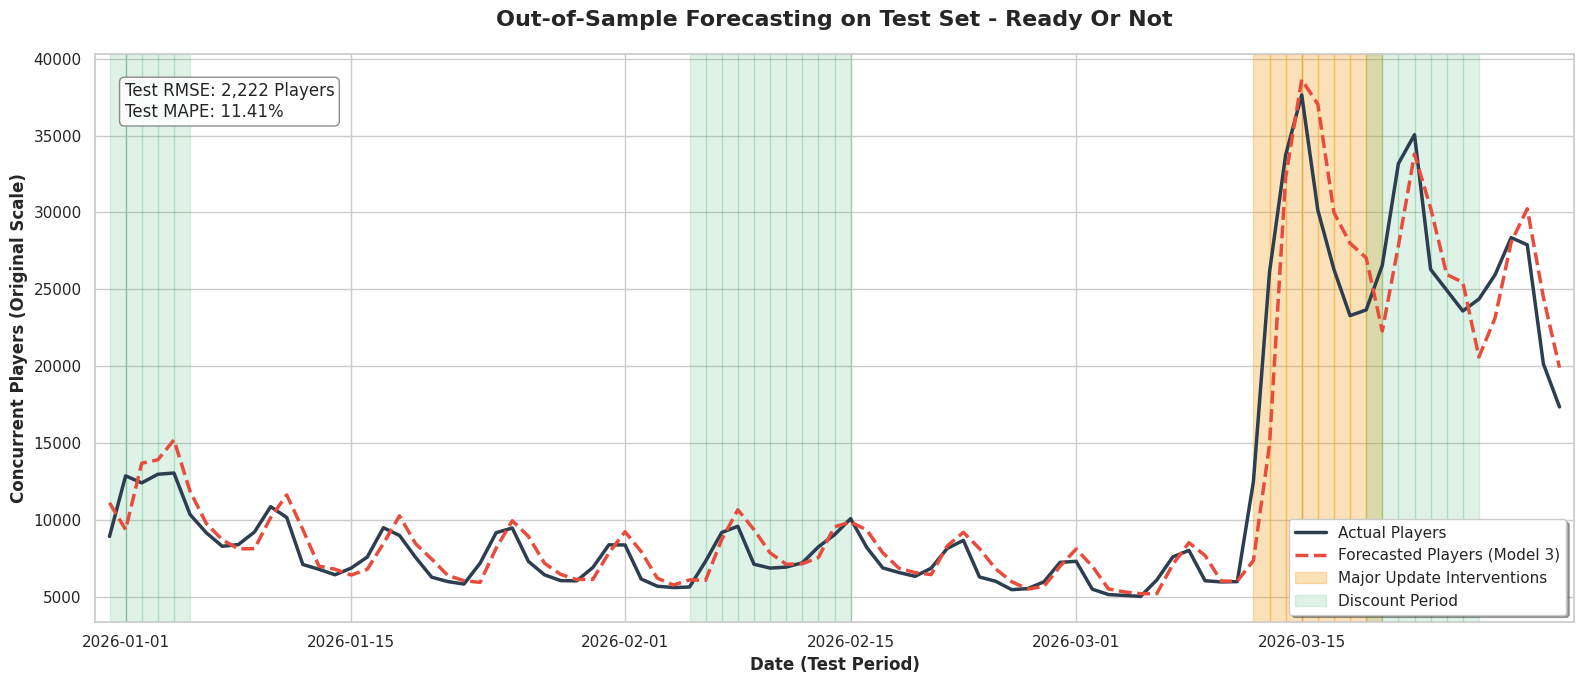

In [9]:
plt.figure(figsize=(16, 7))

sns.set_theme(style='whitegrid')

# Plot Actual vs Predicted on Test Set (Original Scale)
plt.plot(test_df.index, test_df['Actual_Players'], label='Actual Players', color='#2c3e50', linewidth=2.5)
plt.plot(test_df.index, test_df['Predicted_Players'], label='Forecasted Players (Model 3)', color='#e74c3c', linestyle='--', linewidth=2.5)

# Highlight Shocks (Major Updates or Discounts > 0)
import matplotlib.patches as mpatches
handles, labels = plt.gca().get_legend_handles_labels()

update_mask = test_df['Is_Major_Update'] == 1
if update_mask.any():
    for dt in test_df[update_mask].index:
        plt.axvspan(dt, dt + pd.Timedelta(days=1), color='#f39c12', alpha=0.3)
    update_patch = mpatches.Patch(color='#f39c12', alpha=0.3, label='Major Update Interventions')
    handles.append(update_patch)
    labels.append('Major Update Interventions')

discount_mask = test_df['Discount_Ratio'] > 0
if discount_mask.any():
    for dt in test_df[discount_mask].index:
        plt.axvspan(dt, dt + pd.Timedelta(days=1), color='#27ae60', alpha=0.15)
    disc_patch = mpatches.Patch(color='#27ae60', alpha=0.15, label='Discount Period')
    handles.append(disc_patch)
    labels.append('Discount Period')

plt.title('Out-of-Sample Forecasting on Test Set - Ready Or Not', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date (Test Period)', fontsize=12, fontweight='bold')
plt.ylabel('Concurrent Players (Original Scale)', fontsize=12, fontweight='bold')
plt.legend(handles, labels, loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.margins(x=0.01)

# Evaluation Box
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
textstr = f"Test RMSE: {rmse:,.0f} Players\nTest MAPE: {mape:.2f}%"
plt.gca().text(0.02, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()
